In [1]:
from imolcraft.calculator import DihedralCalculator, load_g16scan
from imolcraft.io.rdkit import atoms2rdkit
from imolcraft.trainer.dmff_utils import  *
from imolcraft.trainer import DihedralTrainer
from imolcraft.trainer.loss import loss_energy
from ase.io import read
from functools import partial

import matplotlib.pyplot as plt
import copy

Warning on use of the timeseries module: If the inherent timescales of the system are long compared to those being analyzed, this statistical inefficiency may be an underestimate.  The estimate presumes the use of many statistically independent samples.  Tests should be performed to assess whether this condition is satisfied.   Be cautious in the interpretation of the data.


In [2]:
pdbfile = "dmc.pdb"
atoms = read(pdbfile)
mol, mol2d, _ = atoms2rdkit(atoms)
calculator = DihedralCalculator(atoms, "dmc", directory="temp_directory")
calculator.scan_list

[[1, 0, 2, 8], [1, 0, 3, 4], [0, 2, 8, 9], [0, 3, 4, 5]]

In [3]:
# If you want to calculate dihedral potential energy surface by G16 or Psi4,
# please execute the following line. It may take times to complete the calculation,
# so you can skip this step if you have already done the calculation and have the log files. 
# calculator.do_qmscan()

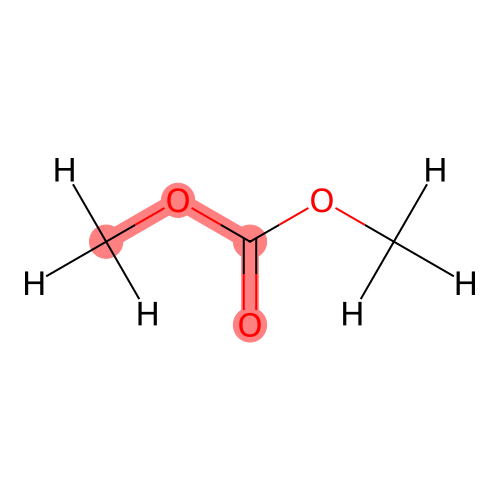

In [4]:
# Highlight the dihedral defined by atoms [1, 0, 3, 4] in mol2d
from rdkit.Chem import rdDepictor
from rdkit.Chem.Draw import rdMolDraw2D
from IPython.display import Image, display

# Do not show H atoms
rdDepictor.Compute2DCoords(mol2d)
d = rdMolDraw2D.MolDraw2DCairo(500, 500)

# Highlight the dihedral defined by atoms [1, 0, 3, 4] in mol2d with light colors
highlight_atoms = [1, 0, 3, 4]
highlight_atom_colors = {idx: (1, 0.5, 0.5) for idx in highlight_atoms}
d.DrawMolecule(mol2d, highlightAtoms=highlight_atoms, highlightAtomColors=highlight_atom_colors)
d.FinishDrawing()

with open("dmc_dihedral.png", "wb") as f:
    f.write(d.GetDrawingText())

display(Image(data=d.GetDrawingText()))

In [5]:
# from ase.visualize import view

# # You can check dihedral atom index -> 1,0,2,8 visually
# view(load_g16scan("dmc_dihed_0.log")[2])
# # check dihedral atom index -> 0,2,8,9
# view(load_g16scan("dmc_dihed_2.log")[2])

In [6]:
# Select the dihedral parameter optimization
# If you calculate all the dihedral by G16 or Psi4, you can skip this cell. 
calculator.scan_list  = [calculator.scan_list[0] , calculator.scan_list[2]]
calculator.qm_calculators = [calculator.qm_calculators[0], calculator.qm_calculators[2]]
calculator.ff_calculators = [calculator.ff_calculators[0], calculator.ff_calculators[2]]
calculator.qm_scan = [calculator.qm_scan[0], calculator.qm_scan[2]]
calculator.ff_scan = [calculator.ff_scan[0], calculator.ff_scan[2]]

calculator.qm_scan[0]["angle_deg"], \
calculator.qm_scan[0]["energy_kjmol"], \
calculator.qm_scan[0]["atoms"], \
      = load_g16scan("dmc_dihed_0.log")

calculator.qm_scan[1]["angle_deg"], \
calculator.qm_scan[1]["energy_kjmol"], \
calculator.qm_scan[1]["atoms"], \
      = load_g16scan("dmc_dihed_2.log")

In [7]:
calculator.do_ffscan("dmc.xml", angles="QM", ini_geom="FF")

In [8]:
# Later used
ff0_origin = copy.deepcopy(calculator.ff_scan[0]["energy_kjmol"])
ff1_origin = copy.deepcopy(calculator.ff_scan[1]["energy_kjmol"])

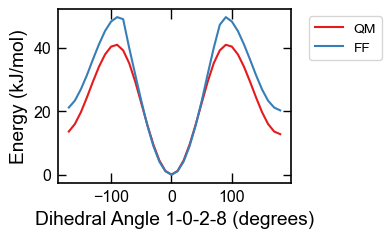

In [9]:
plt.plot(calculator.qm_scan[0]["angle_deg"], calculator.qm_scan[0]["energy_kjmol"], label="QM")
plt.plot(calculator.ff_scan[0]["angle_deg"], calculator.ff_scan[0]["energy_kjmol"], label="FF")
dihedral_name = "-".join(str(x) for x in calculator.scan_list[0])
plt.xlabel(f"Dihedral Angle {dihedral_name} (degrees)")
plt.ylabel("Energy (kJ/mol)")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

/var/folders/xg/61nh98bx4jz721g8yhclgq140000gn/T/ipykernel_59790/761895885.py:6: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')


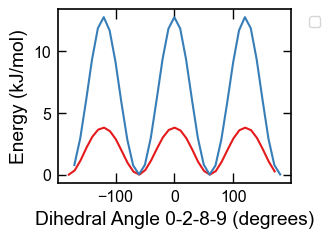

In [10]:
plt.plot(calculator.qm_scan[1]["angle_deg"], calculator.qm_scan[1]["energy_kjmol"])
plt.plot(calculator.ff_scan[1]["angle_deg"], calculator.ff_scan[1]["energy_kjmol"])
dihedral_name = "-".join(str(x) for x in calculator.scan_list[1])
plt.xlabel(f"Dihedral Angle {dihedral_name} (degrees)")
plt.ylabel("Energy (kJ/mol)")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

In [11]:
# define the loss function for dihedral parameter optimization
lossfn = partial(loss_energy, weight_scheme="uniform", zeropoint="qmmin")

In [12]:
tr = DihedralTrainer(
    ffxml="dmc.xml",
    pdbfile=pdbfile,
    calculator=calculator,
    loss_fn=lossfn,
    opt_fftypes=["PeriodicTorsionForce/proper_k"],
    relax_steps=1,
    lr=0.1,
    clip=0.5
)

In [13]:
tr.setup()

In [14]:
# At the beginning, the FF energy is far from QM energy,
# so we perform relaxed scan with the updated force field at each parameter update.
tr.fit(steps=10)

grad obtained.... Memory Usage: 843.30 MB
grad modify.... Memory Usage: 844.91 MB
update finished.... Memory Usage: 859.89 MB
Epoch 0, Loss: 15.387583078026235, Memory Usage: 912.59 MB
Loss:  15.387583078026235
Best Loss:  15.387583078026235 at epoch  0
Epoch 0 completed in 17.59 seconds.
----
grad obtained.... Memory Usage: 947.64 MB
grad modify.... Memory Usage: 947.64 MB
update finished.... Memory Usage: 947.64 MB
Loss:  11.278047999037689
Best Loss:  11.278047999037689 at epoch  1
Epoch 1 completed in 16.48 seconds.
----
grad obtained.... Memory Usage: 974.44 MB
grad modify.... Memory Usage: 974.44 MB
update finished.... Memory Usage: 974.44 MB
Loss:  9.697330883883254
Best Loss:  9.697330883883254 at epoch  2
Epoch 2 completed in 16.37 seconds.
----
grad obtained.... Memory Usage: 1019.08 MB
grad modify.... Memory Usage: 1019.08 MB
update finished.... Memory Usage: 1019.08 MB
Loss:  8.306175287696144
Best Loss:  8.306175287696144 at epoch  3
Epoch 3 completed in 16.30 seconds.
---

In [15]:
# Perform a relaxed scan every 25 steps of parameter update to update the scanned structures.
tr.relax_steps = 25
tr.fit(steps=100)

grad obtained.... Memory Usage: 1292.52 MB
grad modify.... Memory Usage: 1292.52 MB
update finished.... Memory Usage: 1292.52 MB
Loss:  1.3541647568594257
Best Loss:  1.3541647568594257 at epoch  11
Epoch 11 completed in 0.03 seconds.
----
grad obtained.... Memory Usage: 1292.52 MB
grad modify.... Memory Usage: 1292.52 MB
update finished.... Memory Usage: 1292.52 MB
Loss:  0.9891161891127188
Best Loss:  0.9891161891127188 at epoch  12
Epoch 12 completed in 0.02 seconds.
----
grad obtained.... Memory Usage: 1292.52 MB
grad modify.... Memory Usage: 1292.52 MB
update finished.... Memory Usage: 1292.52 MB
Loss:  0.715345043580948
Best Loss:  0.715345043580948 at epoch  13
Epoch 13 completed in 0.02 seconds.
----
grad obtained.... Memory Usage: 1292.52 MB
grad modify.... Memory Usage: 1292.52 MB
update finished.... Memory Usage: 1292.52 MB
Loss:  0.5232193477851976
Best Loss:  0.5232193477851976 at epoch  14
Epoch 14 completed in 0.02 seconds.
----
grad obtained.... Memory Usage: 1292.52 MB

Text(0.5, 1.0, 'Training Loss')

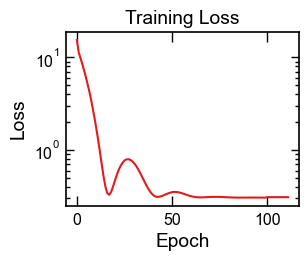

In [16]:
# Plot the loss curve
plt.yscale("log")
plt.plot(tr.epochs, tr.losses)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss")

In [17]:
# After optimization, the FF energy is calculated using the best optimized FF parameters.
calculator.do_ffscan("dmc1_best.xml", angles="QM", ini_geom="FF")

Text(0, 0.5, 'Energy (kJ/mol)')

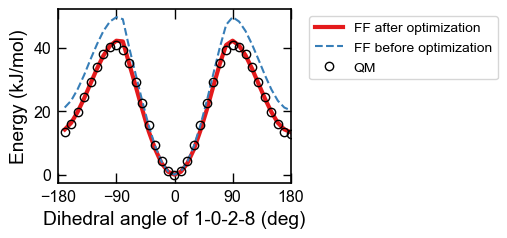

In [18]:
plt.xlim(-180,180)
plt.xticks([-180, -90, 0, 90, 180])
plt.plot(np.array(calculator.ff_scan[0]["angle_deg"]),
         calculator.ff_scan[0]["energy_kjmol"],
         linewidth=3,
         label="FF after optimization")
plt.plot(calculator.ff_scan[0]["angle_deg"], ff0_origin, linestyle='--', label="FF before optimization")
plt.plot(calculator.qm_scan[0]["angle_deg"], calculator.qm_scan[0]["energy_kjmol"], marker="o", linestyle='None', color="black", fillstyle='none', label="QM")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
dihedral_name = "-".join(str(x) for x in calculator.scan_list[0])
plt.xlabel(f"Dihedral angle of {dihedral_name} (deg)")
plt.ylabel("Energy (kJ/mol)")

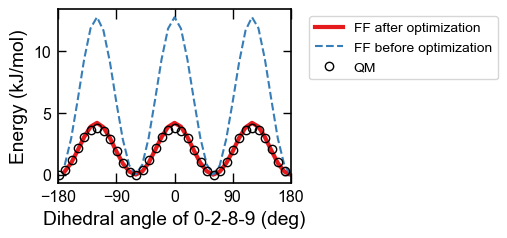

In [19]:
plt.xlim(-180,180)
plt.xticks([-180, -90, 0, 90, 180])
plt.plot(np.array(calculator.ff_scan[1]["angle_deg"]),
         calculator.ff_scan[1]["energy_kjmol"],
         linewidth=3,
         label="FF after optimization")
plt.plot(calculator.ff_scan[1]["angle_deg"], ff1_origin, linestyle='--', label="FF before optimization")
plt.plot(calculator.qm_scan[1]["angle_deg"], calculator.qm_scan[1]["energy_kjmol"], marker="o", linestyle='None', color="black", fillstyle='none', label="QM")
dihedral_name = "-".join(str(x) for x in calculator.scan_list[1])
plt.xlabel(f"Dihedral angle of {dihedral_name} (deg)")
plt.ylabel("Energy (kJ/mol)")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')